# 03 v2 — Candidate walking-route PM₂.₅ exposure using CAFEIN

**Purpose.** Re-run the Stage 03 walking-route proof of concept using CAFEIN's native street-routing and environmental-exposure workflow, so the results can be compared with the original OSMnx + custom 20 m raster-sampling notebook.

This notebook follows the CAFEIN documentation sequence:

1. load the Helsinki sample OSM/DEM inputs;
2. build `StreetNetwork` with `StreetNetwork.from_osm(...)` if the saved artifact does not already exist;
3. save/load `helsinki-region-streets.cafein`;
4. attach the FMI PM₂.₅ raster using `Exposure`;
5. route the same candidate OD pairs using `DetailedItineraries(..., transport_mode="walk")`;
6. export CAFEIN's `pm25_mean`, `pm25_max`, `pm25_coverage`, travel time, distance, and route geometry.

**Important.** The CAFEIN mobility OD flows do not identify travel mode or observed trajectories. These remain **candidate walking routes**, not observed walking trips.


## 1. Imports and output paths

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio

import cafein.sampledata.helsinki as helsinki
from cafein import DetailedItineraries, Exposure, StreetNetwork

OUTPUT_DIR = Path("../outputs/v2/03_candidate_walking_route_pm25_exposure")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STREET_NETWORK_PATH = Path("helsinki-region-streets.cafein")

print("Output directory:", OUTPUT_DIR.resolve())
print("Street artifact:", STREET_NETWORK_PATH.resolve())


Output directory: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v2/03_candidate_walking_route_pm25_exposure
Street artifact: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/notebooks/helsinki-region-streets.cafein


## 2. Build or load the CAFEIN street network

The CAFEIN standalone street-routing guide builds the Helsinki graph from the packaged OpenStreetMap extract and DEM:

```python
StreetNetwork.from_osm(
    osm,
    modes=("walk", "bicycle", "e_scooter", "wheelchair", "car"),
    dem=dem,
    dem_interval=25,
    country="FI",
)
```

The graph is then saved as `helsinki-region-streets.cafein`.

This cell does that automatically the first time. Later runs reuse the saved artifact.


In [6]:
osm = helsinki.osm_pbf
dem = helsinki.dem

if STREET_NETWORK_PATH.exists():
    print("Loading existing CAFEIN street network...")
    street_network = StreetNetwork.load(STREET_NETWORK_PATH)
else:
    print("Building CAFEIN street network from the Helsinki OSM extract...")
    print("This is the expensive one-time step.")

    street_network = StreetNetwork.from_osm(
        osm,
        modes=("walk", "bicycle", "e_scooter", "wheelchair", "car"),
        dem=dem,
        dem_interval=25,
        country="FI",
    )

    street_network.save(STREET_NETWORK_PATH)
    print("Saved:", STREET_NETWORK_PATH.resolve())

print("Vertices:", street_network.vertex_count)
print("Edges:", street_network.edge_count)


Building CAFEIN street network from the Helsinki OSM extract...
This is the expensive one-time step.
Saved: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/notebooks/helsinki-region-streets.cafein
Vertices: 1474309
Edges: 1644890


## 3. Re-create the same OD preparation used in Stage 03 v1

In [7]:
od = pd.read_parquet(helsinki.mobility.od_weekday)
presence = pd.read_parquet(helsinki.mobility.presence_weekday)
units = gpd.read_file(helsinki.mobility.neighbourhoods)

units["unit_id"] = units["Neighbourhood_unit_ID"].astype("Int64")
presence["home_unit"] = presence["home_unit"].astype("Int64")
presence["visited_unit"] = presence["visited_unit"].astype("Int64")
od["origin"] = od["origin"].astype("Int64")
od["destination"] = od["destination"].astype("Int64")

unit_lookup = units[
    ["unit_id", "Neighbourhood_name", "Municipality_name", "geometry"]
].copy()

origin_names = unit_lookup[
    ["unit_id", "Neighbourhood_name"]
].rename(columns={
    "unit_id": "origin",
    "Neighbourhood_name": "origin_name"
})

destination_names = unit_lookup[
    ["unit_id", "Neighbourhood_name"]
].rename(columns={
    "unit_id": "destination",
    "Neighbourhood_name": "destination_name"
})

od_geo = (
    od
    .merge(origin_names, on="origin", how="left")
    .merge(destination_names, on="destination", how="left")
)

print("OD rows:", len(od_geo))
display(od_geo.head())


OD rows: 1580938


,origin,destination,hour,trips,origin_name,destination_name
0,491011111,491011112,0,59.896716,Pohjois-Leppävaara,Etelä-Leppävaara
1,491011111,491011113,0,39.964573,Pohjois-Leppävaara,Mäkkylä
2,491011111,491011114,0,4.011500,Pohjois-Leppävaara,Lintukorpi
3,491011111,491011115,0,10.129039,Pohjois-Leppävaara,Lintulaakso
4,491011111,491011116,0,17.086485,Pohjois-Leppävaara,Uusmäki


## 4. Identify neighbourhoods covered by the FMI PM₂.₅ raster

This keeps the same representative-point logic as Stage 03 v1 so that the v1/v2 comparison changes the **routing/exposure engine**, not the OD selection.


In [8]:
unit_pm = units[
    ["unit_id", "Neighbourhood_name", "Municipality_name", "geometry"]
].copy()

with rasterio.open(helsinki.air_quality) as src:
    unit_pm = unit_pm.to_crs(src.crs)
    unit_pm["sample_point"] = unit_pm.geometry.representative_point()

    xmin = min(src.bounds.left, src.bounds.right)
    xmax = max(src.bounds.left, src.bounds.right)
    ymin = min(src.bounds.bottom, src.bounds.top)
    ymax = max(src.bounds.bottom, src.bounds.top)

    def sample_pm25(point):
        x, y = point.x, point.y

        if not (xmin <= x <= xmax and ymin <= y <= ymax):
            return np.nan

        value = next(src.sample([(x, y)], indexes=5, masked=True))[0]

        if np.ma.is_masked(value):
            return np.nan

        value = float(value)
        return value if value > 0 else np.nan

    unit_pm["pm25_at_representative_point"] = unit_pm["sample_point"].apply(sample_pm25)

print("Neighbourhoods with valid PM2.5:",
      unit_pm["pm25_at_representative_point"].notna().sum(),
      "of", len(unit_pm))


Neighbourhoods with valid PM2.5: 284 of 298


## 5. Select the same type of top candidate OD pairs

In [9]:
origin_pm_for_od = unit_pm[
    ["unit_id", "pm25_at_representative_point"]
].rename(columns={
    "unit_id": "origin",
    "pm25_at_representative_point": "origin_pm25"
})

destination_pm_for_od = unit_pm[
    ["unit_id", "pm25_at_representative_point"]
].rename(columns={
    "unit_id": "destination",
    "pm25_at_representative_point": "destination_pm25"
})

route_od = (
    od_geo
    .merge(origin_pm_for_od, on="origin", how="left")
    .merge(destination_pm_for_od, on="destination", how="left")
)

route_od = route_od[
    route_od["origin_pm25"].notna()
    & route_od["destination_pm25"].notna()
    & (route_od["origin"] != route_od["destination"])
].copy()

od_pairs = (
    route_od
    .groupby(
        ["origin", "origin_name", "destination", "destination_name"],
        as_index=False
    )
    .agg(trips=("trips", "sum"))
)

top_pairs = (
    od_pairs
    .sort_values("trips", ascending=False)
    .head(100)
    .copy()
)

points = unit_pm[["unit_id", "sample_point"]].copy()

top_pairs = (
    top_pairs
    .merge(
        points.rename(columns={
            "unit_id": "origin",
            "sample_point": "origin_point"
        }),
        on="origin",
        how="left"
    )
    .merge(
        points.rename(columns={
            "unit_id": "destination",
            "sample_point": "destination_point"
        }),
        on="destination",
        how="left"
    )
)

test_pairs = top_pairs.head(5).copy()

display(test_pairs[
    ["origin", "origin_name", "destination", "destination_name", "trips"]
])


,origin,origin_name,destination,destination_name,trips
0,911103203,Jätkäsaari,911103040,Kamppi,7833.721931
1,911103130,Etu-Töölö,911103040,Kamppi,7708.390583
2,911104140,Taka-Töölö,911103130,Etu-Töölö,7561.684670
3,921015000,Myyrmäki,921017000,Martinlaakso,7375.596901
4,911102050,Punavuori,911103040,Kamppi,7267.193618


## 6. Build CAFEIN origin and destination GeoDataFrames

CAFEIN's `DetailedItineraries` expects point GeoDataFrames. Points use normal Shapely order: **Point(longitude, latitude)**. The representative points above are already in the raster CRS; we explicitly convert them to EPSG:4326.


In [10]:
pair_rows = []

for i, row in test_pairs.reset_index(drop=True).iterrows():
    pair_id = f"pair_{i+1}"

    pair_rows.append({
        "pair_id": pair_id,
        "origin": int(row["origin"]),
        "origin_name": row["origin_name"],
        "destination": int(row["destination"]),
        "destination_name": row["destination_name"],
        "trips": row["trips"],
        "origin_point": row["origin_point"],
        "destination_point": row["destination_point"],
    })

pairs = pd.DataFrame(pair_rows)

origins = gpd.GeoDataFrame(
    {
        "id": pairs["pair_id"],
        "origin_name": pairs["origin_name"],
    },
    geometry=pairs["origin_point"],
    crs=unit_pm.crs,
).to_crs("EPSG:4326")

destinations = gpd.GeoDataFrame(
    {
        "id": pairs["pair_id"],
        "destination_name": pairs["destination_name"],
    },
    geometry=pairs["destination_point"],
    crs=unit_pm.crs,
).to_crs("EPSG:4326")

display(origins)
display(destinations)


,id,origin_name,geometry
0,pair_1,Jätkäsaari,POINT (24.91016 60.15291)
1,pair_2,Etu-Töölö,POINT (24.91024 60.17426)
2,pair_3,Taka-Töölö,POINT (24.9188 60.18405)
3,pair_4,Myyrmäki,POINT (24.84974 60.26366)
4,pair_5,Punavuori,POINT (24.93496 60.16106)


,id,destination_name,geometry
0,pair_1,Kamppi,POINT (24.93206 60.16631)
1,pair_2,Kamppi,POINT (24.93206 60.16631)
2,pair_3,Etu-Töölö,POINT (24.91024 60.17426)
3,pair_4,Martinlaakso,POINT (24.85049 60.28131)
4,pair_5,Kamppi,POINT (24.93206 60.16631)


## 7. Attach PM₂.₅ to the CAFEIN street network

This is the key methodological change from Stage 03 v1.

Instead of manually sampling a routed line every 20 m, CAFEIN's `Exposure` samples the environmental raster onto street edges and then reports route-level exposure metrics.


In [11]:
street_pollution = Exposure(
    street_network,
    pm25=(helsinki.air_quality, "PM25Concentration"),
)

print("Exposure layers:", street_pollution.layers)
print("Exposure columns:", street_pollution.column_names())


Exposure layers: ('pm25',)
Exposure columns: ['pm25_mean', 'pm25_max', 'pm25_coverage']


## 8. Route each OD pair with CAFEIN

We route one pair at a time so each origin is matched only to its intended destination. `DetailedItineraries` returns the geometry-bearing walking leg and CAFEIN exposure fields.


In [12]:
itineraries = []

for i, row in pairs.iterrows():
    pair_id = row["pair_id"]

    origin_one = origins.loc[origins["id"] == pair_id, ["id", "geometry"]].copy()
    destination_one = destinations.loc[destinations["id"] == pair_id, ["id", "geometry"]].copy()

    try:
        itinerary = DetailedItineraries(
            street_network,
            origin_one,
            destination_one,
            transport_mode="walk",
            exposure=street_pollution,
        )

        itinerary = itinerary.copy()
        itinerary["pair_id"] = pair_id
        itinerary["origin_name"] = row["origin_name"]
        itinerary["destination_name"] = row["destination_name"]
        itinerary["trips"] = row["trips"]

        itineraries.append(itinerary)

    except Exception as exc:
        print(
            f"{pair_id}: route failed "
            f"({row['origin_name']} -> {row['destination_name']}): {exc}"
        )

if not itineraries:
    raise RuntimeError("CAFEIN did not return any routes for the five test OD pairs.")

routes_cafein = gpd.GeoDataFrame(
    pd.concat(itineraries, ignore_index=True),
    geometry="geometry",
    crs=itineraries[0].crs,
)

print("CAFEIN route rows:", len(routes_cafein))
display(routes_cafein.head())


CAFEIN route rows: 5


,from_id,to_id,option,segment,leg_type,mode,departure_s,arrival_s,travel_time,distance_m,...,distance_provenance,emissions,pm25_mean,pm25_max,pm25_coverage,geometry,pair_id,origin_name,destination_name,trips
0,pair_1,pair_1,0,0,walk,walk,<NA>,<NA>,37,2205.684412,...,osm_edge_length+geodesic_connector,0.0,2.744701,4.6,1.0,"LINESTRING (24.91016 60.15291, 24.91016 60.152...",pair_1,Jätkäsaari,Kamppi,7833.721931
1,pair_2,pair_2,0,0,walk,walk,<NA>,<NA>,29,1734.204937,...,osm_edge_length+geodesic_connector,0.0,2.775638,3.9,1.0,"LINESTRING (24.91024 60.17426, 24.9102 60.1743...",pair_2,Etu-Töölö,Kamppi,7708.390583
2,pair_3,pair_3,0,0,walk,walk,<NA>,<NA>,24,1424.956762,...,osm_edge_length+geodesic_connector,0.0,2.772966,3.5,1.0,"LINESTRING (24.9188 60.18405, 24.91873 60.1840...",pair_3,Taka-Töölö,Etu-Töölö,7561.684670
3,pair_4,pair_4,0,0,walk,walk,<NA>,<NA>,42,2516.637468,...,osm_edge_length+geodesic_connector,0.0,2.304843,2.6,1.0,"LINESTRING (24.84974 60.26366, 24.84975 60.263...",pair_4,Myyrmäki,Martinlaakso,7375.596901
4,pair_5,pair_5,0,0,walk,walk,<NA>,<NA>,13,793.695926,...,osm_edge_length+geodesic_connector,0.0,2.930872,3.5,1.0,"LINESTRING (24.93496 60.16106, 24.93503 60.161...",pair_5,Punavuori,Kamppi,7267.193618


## 9. Create the v2 comparison table

CAFEIN normally reports `travel_time`, `distance_m`, `pm25_mean`, `pm25_max`, and `pm25_coverage` for a standalone street itinerary.

The code below keeps only columns that are present in the installed CAFEIN version.


In [13]:
wanted = [
    "pair_id",
    "origin_name",
    "destination_name",
    "trips",
    "travel_time",
    "distance_m",
    "pm25_mean",
    "pm25_max",
    "pm25_coverage",
]

available = [c for c in wanted if c in routes_cafein.columns]
comparison_v2 = routes_cafein[available].copy()

# CAFEIN documentation reports travel_time in minutes for itinerary tables.
if "travel_time" in comparison_v2.columns:
    comparison_v2 = comparison_v2.rename(
        columns={"travel_time": "cafein_walk_time_min"}
    )

if "distance_m" in comparison_v2.columns:
    comparison_v2 = comparison_v2.rename(
        columns={"distance_m": "cafein_route_length_m"}
    )

if "pm25_mean" in comparison_v2.columns:
    comparison_v2 = comparison_v2.rename(
        columns={"pm25_mean": "cafein_mean_route_pm25"}
    )

if "pm25_max" in comparison_v2.columns:
    comparison_v2 = comparison_v2.rename(
        columns={"pm25_max": "cafein_max_route_pm25"}
    )

if "pm25_coverage" in comparison_v2.columns:
    comparison_v2 = comparison_v2.rename(
        columns={"pm25_coverage": "cafein_pm25_coverage"}
    )

if {
    "cafein_walk_time_min",
    "cafein_mean_route_pm25",
}.issubset(comparison_v2.columns):
    comparison_v2["cafein_pm25_time_burden"] = (
        comparison_v2["cafein_walk_time_min"]
        * comparison_v2["cafein_mean_route_pm25"]
    )

display(comparison_v2)


,pair_id,origin_name,destination_name,trips,cafein_walk_time_min,cafein_route_length_m,cafein_mean_route_pm25,cafein_max_route_pm25,cafein_pm25_coverage,cafein_pm25_time_burden
0,pair_1,Jätkäsaari,Kamppi,7833.721931,37,2205.684412,2.744701,4.6,1.0,101.553924
1,pair_2,Etu-Töölö,Kamppi,7708.390583,29,1734.204937,2.775638,3.9,1.0,80.493498
2,pair_3,Taka-Töölö,Etu-Töölö,7561.684670,24,1424.956762,2.772966,3.5,1.0,66.551189
3,pair_4,Myyrmäki,Martinlaakso,7375.596901,42,2516.637468,2.304843,2.6,1.0,96.803416
4,pair_5,Punavuori,Kamppi,7267.193618,13,793.695926,2.930872,3.5,1.0,38.101340


## 10. Save v2 outputs for direct comparison with Stage 03 v1

In [14]:
comparison_csv = OUTPUT_DIR / "stage03_cafein_v2_route_exposure.csv"
routes_gpkg = OUTPUT_DIR / "stage03_cafein_v2_routes.gpkg"

comparison_v2.to_csv(comparison_csv, index=False)
routes_cafein.to_file(routes_gpkg, layer="cafein_routes", driver="GPKG")

print("Saved:", comparison_csv)
print("Saved:", routes_gpkg)


Saved: ../outputs/v2/03_candidate_walking_route_pm25_exposure/stage03_cafein_v2_route_exposure.csv
Saved: ../outputs/v2/03_candidate_walking_route_pm25_exposure/stage03_cafein_v2_routes.gpkg


## 11. Map the CAFEIN routes over the FMI PM₂.₅ surface

This is the v2 equivalent of the final map in Stage 03 v1.


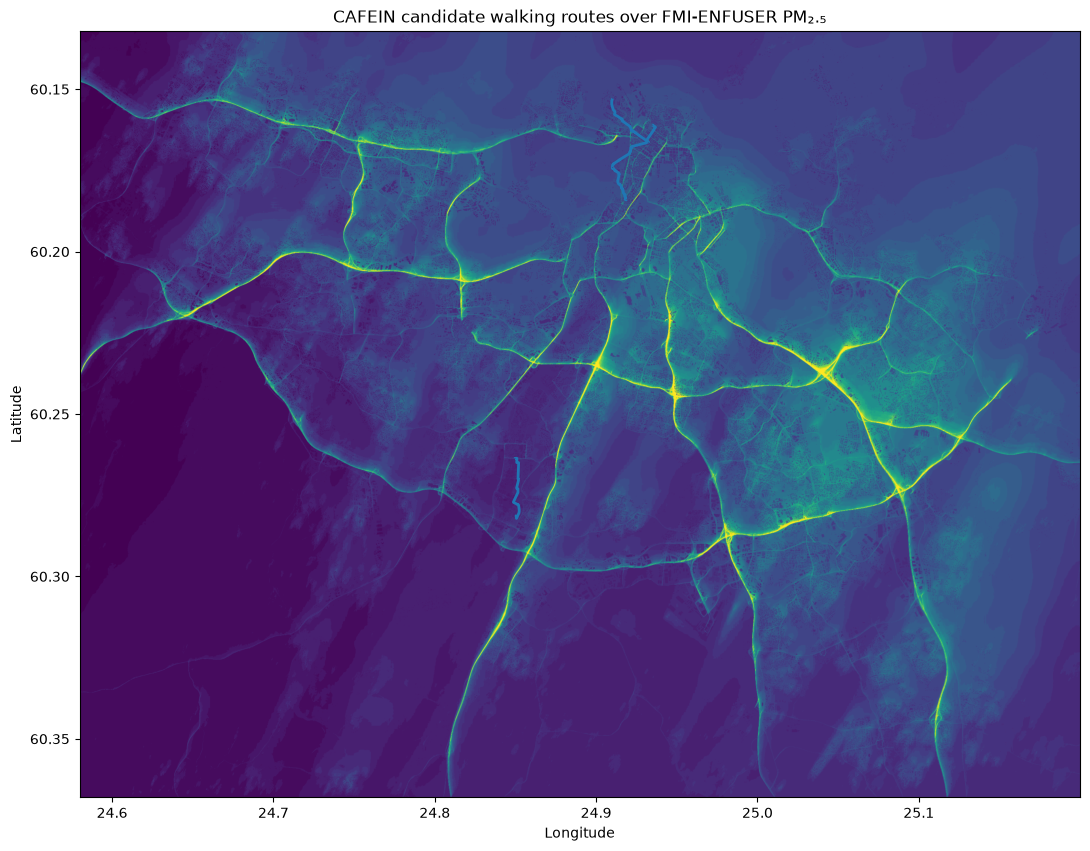

In [15]:
from rasterio.plot import show

routes_wgs84 = routes_cafein.to_crs("EPSG:4326")

with rasterio.open(helsinki.air_quality) as src:
    pm25_band = src.read(5)

    fig, ax = plt.subplots(figsize=(11, 9))

    show(
        pm25_band,
        transform=src.transform,
        ax=ax,
    )

    routes_wgs84.plot(
        ax=ax,
        linewidth=2,
    )

    ax.set_title("CAFEIN candidate walking routes over FMI-ENFUSER PM₂.₅")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.tight_layout()
    plt.show()


## 12. What to compare with Stage 03 v1

Compare these v2 fields with the original OSMnx/custom-sampling outputs:

| Stage 03 v1 | Stage 03 v2 / CAFEIN |
|---|---|
| `route_length_m` | `cafein_route_length_m` |
| `walk_time_min` | `cafein_walk_time_min` |
| `mean_route_pm25` | `cafein_mean_route_pm25` |
| `max_route_pm25` | `cafein_max_route_pm25` |
| `pm25_sample_coverage_pct` | `cafein_pm25_coverage` |
| `pm25_time_burden` | `cafein_pm25_time_burden` |

Differences are expected because:

- v1 routes with OSMnx and minimizes route length;
- v2 routes with CAFEIN's walking profile and its network representation;
- v1 samples the final route geometry manually every 20 m;
- CAFEIN samples exposure onto network edges (approximately 25 m for raster/line layers in the environmental-exposure guide);
- connector/snap handling can differ between the two routing engines.

The scientific comparison should therefore treat discrepancies as a **methodological sensitivity test**, not automatically as errors.
